# FTD Spike Analysis

This notebook analyzes SEC Fail-to-Deliver data for GME around the May 2024 event.

**Key questions:**
- Did FTD volumes spike around the May 13–17, 2024 options event?
- How do May 2024 FTDs compare to the January 2021 event?
- Do ETF-level FTDs (XRT) show correlated spikes?

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load FTD Data
with open('../results/sec_ftd_gme_may_june_2024.json', 'r') as f:
    data = json.load(f)

print(f"Total data points: {data['gme_summary']['total_data_points']}")
print(f"Total fail shares: {data['gme_summary']['total_fail_shares']:,.0f}")
print(f"Total notional value: ${data['gme_summary']['total_notional']:,.2f}")
print(f"Peak date: {data['gme_summary']['peak_date']}")
print(f"Peak shares failed: {data['gme_summary']['peak_shares']:,.0f}")

Total data points: 67
Total fail shares: 5,495,703
Total notional value: $126,933,956.73
Peak date: 20240515
Peak shares failed: 571,602


## 1. GME FTD Timeline

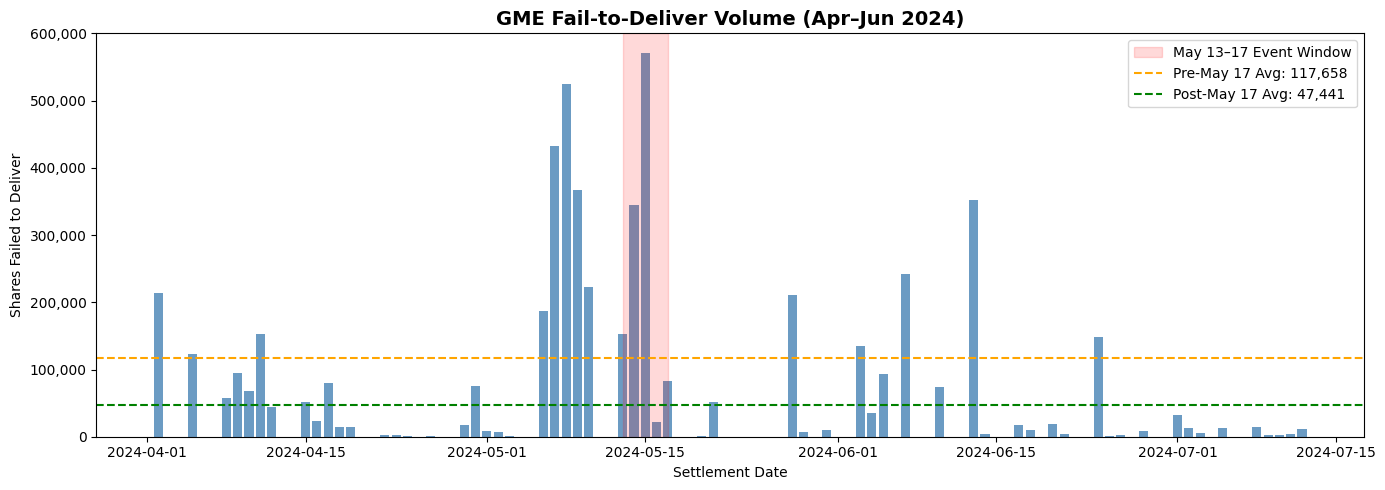


Pre-event average: 117,658 shares/day
Post-event average: 47,441 shares/day
Ratio (pre/post): 2.5x


In [2]:
# Build DataFrame from FTD records
df = pd.DataFrame(data['gme_ftds'])
df['date'] = pd.to_datetime(df['settlement_date'], format='%Y%m%d')
df = df.sort_values('date')

# Mark the event window
event_start = pd.Timestamp('2024-05-13')
event_end = pd.Timestamp('2024-05-17')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df['date'], df['quantity_fails'], color='steelblue', alpha=0.8, width=0.8)
ax.axvspan(event_start, event_end, alpha=0.15, color='red', label='May 13–17 Event Window')
ax.axhline(y=data['gme_summary']['pre_may17_avg'], color='orange', linestyle='--', 
           label=f"Pre-May 17 Avg: {data['gme_summary']['pre_may17_avg']:,.0f}")
ax.axhline(y=data['gme_summary']['post_may17_avg'], color='green', linestyle='--',
           label=f"Post-May 17 Avg: {data['gme_summary']['post_may17_avg']:,.0f}")

ax.set_title('GME Fail-to-Deliver Volume (Apr–Jun 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Settlement Date')
ax.set_ylabel('Shares Failed to Deliver')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nPre-event average: {data['gme_summary']['pre_may17_avg']:,.0f} shares/day")
print(f"Post-event average: {data['gme_summary']['post_may17_avg']:,.0f} shares/day")
print(f"Ratio (pre/post): {data['gme_summary']['pre_may17_avg'] / data['gme_summary']['post_may17_avg']:.1f}x")

## 2. Notional Value of Fails

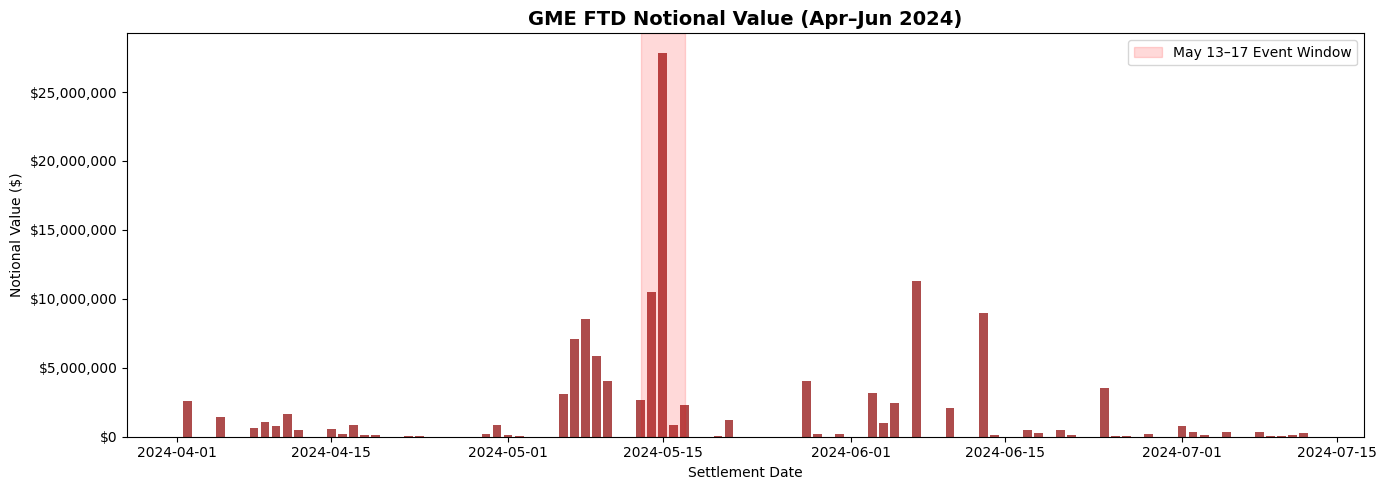


Top 10 FTD Days by Volume:
      Date  Shares Failed  Price  Notional Value
2024-05-15         571602  48.75     27865597.50
2024-05-08         525493  16.31      8570790.83
2024-05-07         433054  16.31      7063110.74
2024-05-09         366850  15.92      5840252.00
2024-06-13         352476  25.46      8974038.96
2024-05-14         344501  30.45     10490055.45
2024-06-07         242827  46.55     11303596.85
2024-05-10         223129  18.01      4018553.29
2024-04-02         214199  11.99      2568246.01
2024-05-28         211603  19.00      4020457.00


In [3]:
# Notional value chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df['date'], df['notional_value'], color='darkred', alpha=0.7, width=0.8)
ax.axvspan(event_start, event_end, alpha=0.15, color='red', label='May 13–17 Event Window')

ax.set_title('GME FTD Notional Value (Apr–Jun 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Settlement Date')
ax.set_ylabel('Notional Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

# Top 10 FTD days
top10 = df.nlargest(10, 'quantity_fails')[['date', 'quantity_fails', 'price', 'notional_value']]
top10['date'] = top10['date'].dt.strftime('%Y-%m-%d')
top10.columns = ['Date', 'Shares Failed', 'Price', 'Notional Value']
print('\nTop 10 FTD Days by Volume:')
print(top10.to_string(index=False))

## 3. January 2021 vs. May 2024 Comparison

In [4]:
# Load Jan 2021 comparison data
with open("../results/phase16c_jan2021_ftd_comparison.json", "r") as f:
    ftd_comp = json.load(f)

# Build comparison table
symbols = ["gme", "amc"]
rows = []
for sym in symbols:
    key = f"{sym}_jan2021"
    records = ftd_comp.get(key, [])
    if isinstance(records, list) and records:
        total_fails = sum(r.get("quantity", r.get("quantity_fails", 0)) for r in records)
        rows.append({"Symbol": sym.upper(), "Period": "Jan 2021", "Total FTDs": total_fails, "Days": len(records)})

# Add May 2024 GME for comparison
rows.append({
    "Symbol": "GME",
    "Period": "May 2024",
    "Total FTDs": data["gme_summary"]["total_fail_shares"],
    "Days": data["gme_summary"]["total_data_points"]
})

comp_df = pd.DataFrame(rows)
comp_df["Avg Daily FTDs"] = (comp_df["Total FTDs"] / comp_df["Days"]).astype(int)
print("FTD Comparison: January 2021 vs. May 2024")
print("=" * 65)
print(comp_df.to_string(index=False))

print(f"Note: Jan 2021 FTD data covers Dec 2020 – Jan 2021 settlement window.")

FTD Comparison: January 2021 vs. May 2024
Symbol   Period  Total FTDs  Days  Avg Daily FTDs
   GME Jan 2021    30955284    60          515921
   AMC Jan 2021   110408461    53         2083178
   GME May 2024     5495703    67           82025
Note: Jan 2021 FTD data covers Dec 2020 – Jan 2021 settlement window.


## 4. Multi-Symbol FTD Correlation (May 2024)

Do correlated FTD spikes across GME, KOSS, and XRT suggest a common hedging mechanism?

May 2024 FTD Data Available For: ['AMC', 'KOSS', 'GME']


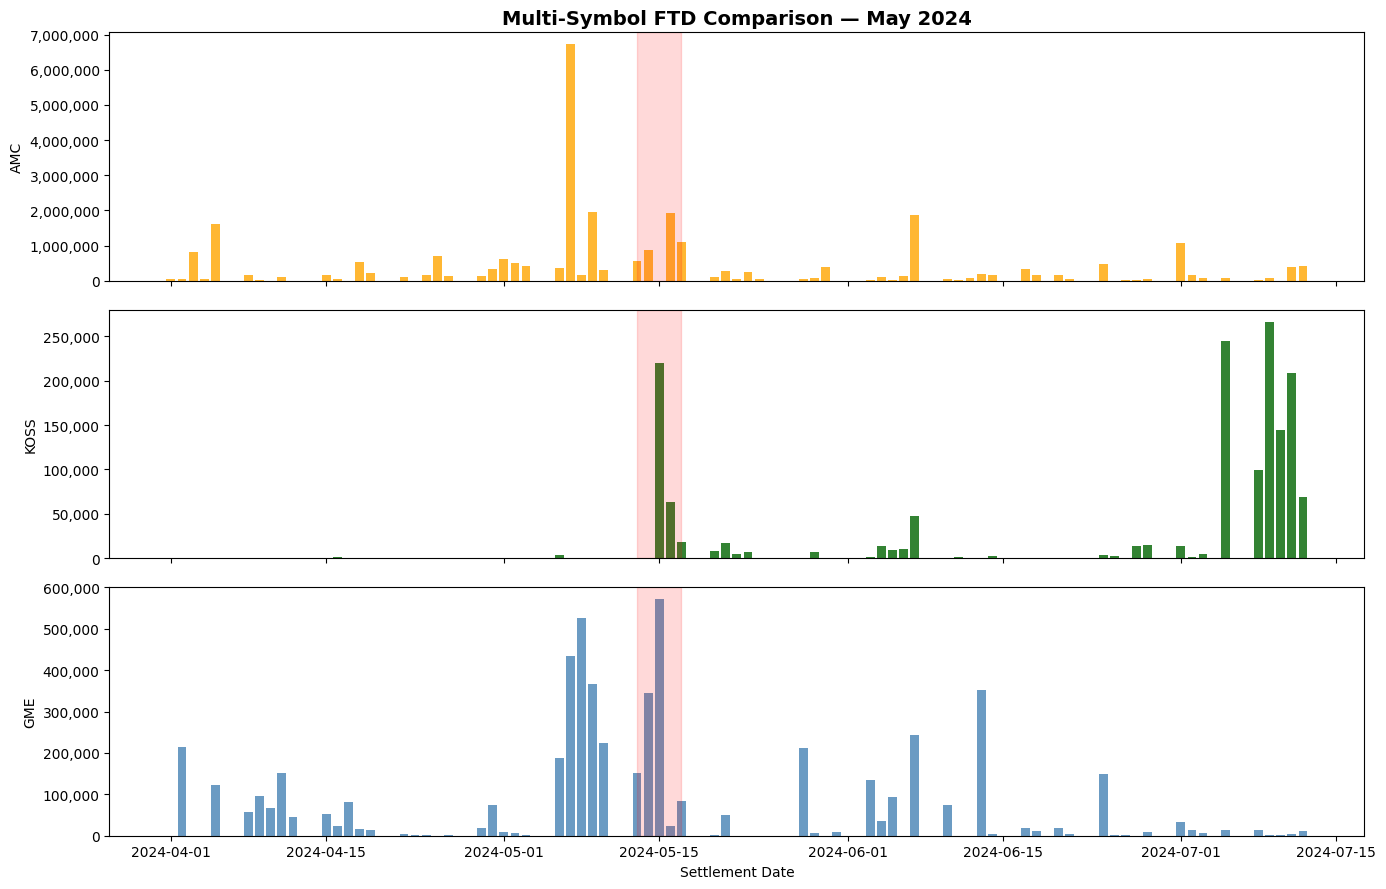

In [5]:
# Load multi-symbol FTD data
with open('../results/sec_ftd_gme_may_june_2024.json', 'r') as f:
    multi_ftd = json.load(f)

may_data = {}
for rec in multi_ftd.get('all_tracked_ftds', []):
    sym = rec.get('symbol')
    if sym:
        may_data.setdefault(sym, []).append(rec)
print('May 2024 FTD Data Available For:', list(may_data.keys()))

# Build per-symbol DataFrames and plot
fig, axes = plt.subplots(len(may_data), 1, figsize=(14, 3 * len(may_data)), sharex=True)
if not hasattr(axes, '__iter__'):
    axes = [axes]

colors = {'GME': 'steelblue', 'KOSS': 'darkgreen', 'XRT': 'purple', 'AMC': 'orange', 'CHWY': 'crimson'}

for ax, (sym, records) in zip(axes, may_data.items()):
    if isinstance(records, list) and records:
        sym_df = pd.DataFrame(records)
        date_col = 'settlement_date' if 'settlement_date' in sym_df.columns else 'SETTLEMENT DATE'
        fail_col = 'quantity_fails' if 'quantity_fails' in sym_df.columns else 'QUANTITY (FAILS)'
        if date_col in sym_df.columns and fail_col in sym_df.columns:
            sym_df['date'] = pd.to_datetime(sym_df[date_col].astype(str), format='%Y%m%d', errors='coerce')
            sym_df = sym_df.dropna(subset=['date']).sort_values('date')
            ax.bar(sym_df['date'], sym_df[fail_col], color=colors.get(sym, 'gray'), alpha=0.8)
            ax.axvspan(event_start, event_end, alpha=0.15, color='red')
    ax.set_ylabel(sym)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[0].set_title('Multi-Symbol FTD Comparison — May 2024', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Settlement Date')
plt.tight_layout()
plt.show()

## 5. ETF Cannibalization: XRT as a Hedging Vehicle

In [6]:
# Compare XRT/GME/KOSS FTDs across both periods
# Load ETF cannibalization data
with open('../results/round12_v1_etf_cannibalization.json', 'r') as f:
    etf_data = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (period, period_data) in zip(axes, etf_data.items()):
    title = period.replace('_', ' ').title()
    syms = []
    totals = []
    for sym_key, records in period_data.items():
        sym = sym_key.replace('_ftds', '').upper()
        if isinstance(records, list) and records:
            if isinstance(records[0], int):
                total = sum(records)
            else:
                total = sum(r.get('quantity_fails', r.get('QUANTITY (FAILS)', 0)) for r in records)
            syms.append(sym)
            totals.append(total)
    
    colors = {'GME': 'steelblue', 'KOSS': 'darkgreen', 'XRT': 'purple'}
    bar_colors = [colors.get(s, 'gray') for s in syms]
    ax.bar(syms, totals, color=bar_colors, alpha=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Total FTDs')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    for i, (s, t) in enumerate(zip(syms, totals)):
        ax.text(i, t + max(totals)*0.02, f'{t:,.0f}', ha='center', fontsize=9)

plt.suptitle('ETF Cannibalization: XRT vs. Constituent FTDs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


MAY 2024
  XRT: 22 days, 2,959,378 total FTDs
  GME: 22 days, 6,411,978 total FTDs
  KOSS: 22 days, 703,464 total FTDs

JAN 2021
  XRT: 29 days, 6,737,167 total FTDs
  GME: 29 days, 16,078,780 total FTDs
  KOSS: 29 days, 916,269 total FTDs


---
*Data source: SEC EDGAR Fail-to-Deliver reports. Analysis code in `../code/analysis/`.*